<a href="https://colab.research.google.com/github/Shalini2374/Phishing-Engine/blob/main/Phishing_CV_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
                                                                                                                                                                                  from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
import os
import zipfile

# --- IMPORTANT: Adjust this path if needed ---
# This assumes you created a 'PhishingProject' folder in your Drive
# and uploaded the zip file there.
zip_path = '/content/drive/MyDrive/phishingproject/cv_data_train.zip'
extract_path = '/content/cv_data_train' # Extract directly into Colab's temporary storage
# ---------------------------------------------

print(f"Looking for zip file at: {zip_path}")
if os.path.exists(zip_path):
    print("Zip file found. Extracting...")
    # Create the extraction directory if it doesn't exist
    if not os.path.exists(extract_path):
        os.makedirs(extract_path)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"Data extracted to: {extract_path}")

    # Verify extraction
    legit_dir = os.path.join(extract_path, 'legitimate')
    phish_dir = os.path.join(extract_path, 'phishing')
    if os.path.isdir(legit_dir) and os.path.isdir(phish_dir):
         print(f"  Legitimate images found: {len(os.listdir(legit_dir))}")
         print(f"  Phishing images found: {len(os.listdir(phish_dir))}")
    else:
         # If extraction didn't create expected folders, check zip structure
         print("[Warning] Could not find 'legitimate' or 'phishing' folders after extraction.")
         print("Please ensure your zip file contains these two folders directly.")
         print("Files/folders found after extraction:", os.listdir(extract_path))

else:
    print(f"[ERROR] Zip file not found at {zip_path}. Please check the path and make sure you uploaded the file to Google Drive.")

# Install necessary libraries (usually pre-installed on Colab, but good practice)
!pip install tensorflow matplotlib Pillow numpy pandas scikit-learn -q
print("\nTensorFlow and other libraries should be ready.")

Looking for zip file at: /content/drive/MyDrive/phishingproject/cv_data_train.zip
Zip file found. Extracting...
Data extracted to: /content/cv_data_train
[Warning] Could not find 'legitimate' or 'phishing' folders after extraction.
Please ensure your zip file contains these two folders directly.
Files/folders found after extraction: ['cv_data_train']

TensorFlow and other libraries should be ready.


--- Phase 4: Training CV Clone Detector Model ---
Found 800 images belonging to 2 classes.
Found 200 images belonging to 2 classes.
Class Indices: {'legitimate': 0, 'phishing': 1}

Building model using MobileNetV2 base...
Compiling model...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Starting model training...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 40s 854ms/step - accuracy: 0.5084 - loss: 0.7964 - val_accuracy: 0.5573 - val_loss: 0.7037
Epoch 2/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 663ms/step - accuracy: 0.5671 - loss: 0.7600 - val_accuracy: 0.5729 - val_loss: 0.6886
Epoch 3/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 639ms/step - accuracy: 0.5436 - loss: 0.7594 - val_accuracy: 0.5625 - val_loss: 0.6757
Epoch 4/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 637ms/step - accuracy: 0.5410 - loss: 0.7573 - val_accuracy: 0.5625 - val_loss: 0.6635
Epoch 5/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 624ms/step - accuracy: 0.6100 - loss: 0.6899 - val_accuracy: 0.5781 - val_loss: 0.6498
Epoch 6/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 620ms/step - accuracy: 0.6109 - loss: 0.6661 - val_accuracy: 0.5729 - val_loss: 0.6407
Epoch 7/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 660ms/step - accuracy: 0.6088 - loss: 0.6792 - val_accuracy: 0.5885 - val_loss: 0.6329
Epoch 8/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 623ms/step - accuracy: 0.6487 - loss: 0.6290 - val_accu

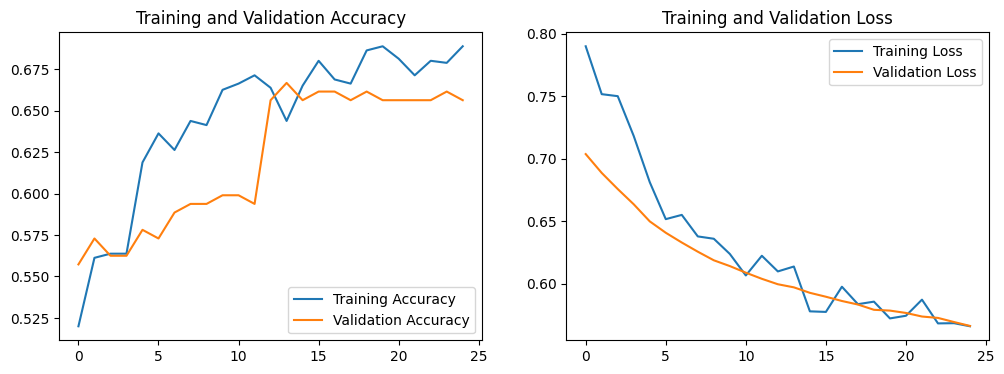


Saving trained model to /content/drive/MyDrive/phishingproject/cv_phishing_model.keras...
Model saved successfully to Google Drive.

--- Phase 4 Finished ---


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import classification_report, confusion_matrix , accuracy_score

# --- Configuration ---
IMAGE_DIR = '/content/cv_data_train/cv_data_train' # <--- CORRECTED PATH # Where we extracted the images
IMG_SIZE = (224, 224) # Input size for MobileNetV2
BATCH_SIZE = 32      # How many images to process at once
EPOCHS = 25         # How many times to go through the entire dataset
LEARNING_RATE = 0.0001
MODEL_SAVE_PATH = '/content/drive/MyDrive/phishingproject/cv_phishing_model.keras' # Save model back to Drive
# ---------------------

print("--- Phase 4: Training CV Clone Detector Model ---")

# 1. Prepare Data Generators
# ImageDataGenerator handles loading images from folders and augmenting them
# Augmentation helps prevent overfitting by slightly modifying images (rotation, zoom etc.)
train_datagen = ImageDataGenerator(
    rescale=1./255,            # Normalize pixel values to 0-1
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2       # Use 20% of the data for validation during training
)

# Training data generator
train_generator = train_datagen.flow_from_directory(
    IMAGE_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',       # binary for 2 classes (legitimate=0, phishing=1)
    subset='training'          # Specify this is the training set
)

# Validation data generator (No augmentation, just rescaling)
validation_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

validation_generator = validation_datagen.flow_from_directory(
    IMAGE_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',       # Specify this is the validation set
    shuffle=False              # No need to shuffle validation data for evaluation
)

# Print class indices to confirm mapping (usually alphabetical: legitimate=0, phishing=1)
print("Class Indices:", train_generator.class_indices)
label_map = {v: k for k, v in train_generator.class_indices.items()} # For later reporting


# 2. Build the Model using Transfer Learning
print("\nBuilding model using MobileNetV2 base...")
# Load MobileNetV2 pre-trained on ImageNet, exclude the final classification layer
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# Freeze the layers of the base model - we don't want to retrain them initially
base_model.trainable = False

# Add our custom classification layers on top
x = base_model.output
x = GlobalAveragePooling2D()(x) # Reduces dimensions
x = Dropout(0.5)(x)             # Regularization to prevent overfitting
# Final output layer: Dense with 1 unit (for binary classification) and sigmoid activation
predictions = Dense(1, activation='sigmoid')(x)

# Combine base model and our custom layers
model = Model(inputs=base_model.input, outputs=predictions)

# 3. Compile the Model
print("Compiling model...")
model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),
              loss='binary_crossentropy', # Suitable for binary classification
              metrics=['accuracy'])

# Print model summary
model.summary()

# 4. Train the Model
print("\nStarting model training...")
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    epochs=EPOCHS
)
print("Model training complete.")

# 5. Evaluate the Model on Validation Set
print("\nEvaluating model performance on validation set...")

# Get predictions (probabilities)
# Ensure validation_generator is reset if used multiple times
validation_generator.reset()
pred_probs = model.predict(validation_generator, steps=validation_generator.samples // BATCH_SIZE + 1)
# Convert probabilities to binary predictions (0 or 1) using 0.5 threshold
y_pred = (pred_probs > 0.5).astype(int).flatten()

# Get true labels
y_true = validation_generator.classes[:len(y_pred)] # Ensure labels match number of predictions made

print("\nClassification Report (CV Model - Validation Set):")
print(classification_report(y_true, y_pred, target_names=label_map.values()))

print("\nConfusion Matrix (CV Model - Validation Set):")
print(confusion_matrix(y_true, y_pred))

acc = accuracy_score(y_true, y_pred)
print(f"\nOverall Validation Accuracy (CV Model): {acc:.4f}")

# 6. Plot Training History (Loss and Accuracy)
print("\nPlotting training history...")
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()


# 7. Save the Trained Model
print(f"\nSaving trained model to {MODEL_SAVE_PATH}...")
model.save(MODEL_SAVE_PATH)
print("Model saved successfully to Google Drive.")

print("\n--- Phase 4 Finished ---")

--- Phase 4 (Re-run): Training CV Model with ResNet50V2 ---
Image directory set to: /content/cv_data_train/cv_data_train
Contents: ['legitimate', 'phishing']

Setting up Data Generators...
Found 800 images belonging to 2 classes.
Found 200 images belonging to 2 classes.
Class Indices: {'legitimate': 0, 'phishing': 1}
Label map created: {0: 'legitimate', 1: 'phishing'}

Building model using ResNet50V2 base...
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Compiling model...


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 58, 58,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 56, 56,    │          0 │ conv2_block1_0_c

 Total params: 23,566,849 (89.90 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,564,800 (89.89 MB)


Starting model training (ResNet50V2)...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 761ms/step - accuracy: 0.5268 - loss: 0.8300 - val_accuracy: 0.6042 - val_loss: 0.6762
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 628ms/step - accuracy: 0.5161 - loss: 0.8084 - val_accuracy: 0.5990 - val_loss: 0.6652
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 639ms/step - accuracy: 0.5996 - loss: 0.6983 - val_accuracy: 0.6250 - val_loss: 0.6523
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 646ms/step - accuracy: 0.5727 - loss: 0.7184 - val_accuracy: 0.6250 - val_loss: 0.6414
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 631ms/step - accuracy: 0.5733 - loss: 0.7117 - val_accuracy: 0.6250 - val_loss: 0.6363
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 632ms/step - accuracy: 0.6489 - loss: 0.6500 - val_accuracy: 0.6146 - val_loss: 0.6304
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 632ms/step - accuracy: 0.6290 - loss: 0.6690 - val_accuracy: 0.6094 - val_loss: 0.6237
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 642ms/step - accuracy: 0.6602 - loss: 0.6164 - val_accu

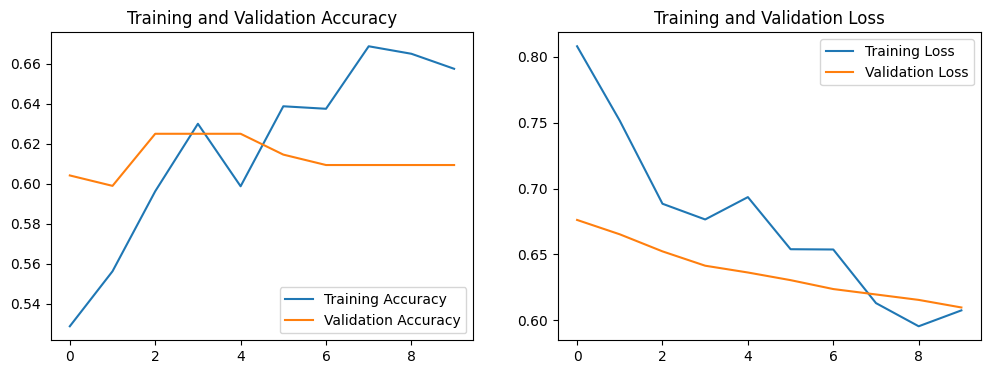


Saving trained model to /content/drive/MyDrive/PhishingProject/cv_phishing_model_resnet50v2.keras...
Model saved successfully to Google Drive.

--- Phase 4 (Re-run with ResNet50V2) Finished ---


In [ ]:
# --------------------------------------------------
# Phase 4: Training CV Model with ResNet50V2
# --------------------------------------------------
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50V2 # Using ResNet50V2
from tensorflow.keras.applications.resnet_v2 import preprocess_input # ResNet50V2 specific preprocessing
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score # Make sure accuracy_score is imported

# --- Configuration ---

# --- !!! IMPORTANT: VERIFY THIS PATH !!! ---
# Check your Colab file browser. Does cv_data_train contain 'legitimate' and 'phishing' directly?
# Or is it nested like cv_data_train/cv_data_train/legitimate? Adjust if needed.
IMAGE_DIR = '/content/cv_data_train/cv_data_train' # <--- ADJUST THIS IF YOUR STRUCTURE IS DIFFERENT
# ----------------------------------------------

IMG_SIZE = (224, 224) # Standard size for ResNet50
BATCH_SIZE = 32      # Keep batch size reasonable for Colab GPU memory (16 or 32)
EPOCHS = 10          # Start with 10 epochs
LEARNING_RATE = 0.0001 # Keep learning rate small for fine-tuning

# --- !!! IMPORTANT: VERIFY THIS GOOGLE DRIVE PATH EXISTS !!! ---
# Make sure you have a 'PhishingProject' folder (or similar) in your Google Drive's main directory.
MODEL_SAVE_PATH = '/content/drive/MyDrive/PhishingProject/cv_phishing_model_resnet50v2.keras' # Saving the new model
# -------------------------------------------------------------

print("--- Phase 4 (Re-run): Training CV Model with ResNet50V2 ---")

# Check if IMAGE_DIR exists and contains expected subfolders
if not os.path.isdir(IMAGE_DIR):
    print(f"[ERROR] IMAGE_DIR '{IMAGE_DIR}' does not exist. Check extraction path and zip file structure.")
elif not os.path.isdir(os.path.join(IMAGE_DIR, 'legitimate')) or not os.path.isdir(os.path.join(IMAGE_DIR, 'phishing')):
    print(f"[ERROR] Could not find 'legitimate' and/or 'phishing' subdirectories directly inside '{IMAGE_DIR}'.")
    print(f"Contents of '{IMAGE_DIR}': {os.listdir(IMAGE_DIR)}")
    print("Please ensure the IMAGE_DIR path points directly to the folder containing 'legitimate' and 'phishing'.")
else:
    print(f"Image directory set to: {IMAGE_DIR}")
    print(f"Contents: {os.listdir(IMAGE_DIR)}")

    # 1. Prepare Data Generators (with ResNet50V2 preprocessing)
    print("\nSetting up Data Generators...")
    train_datagen = ImageDataGenerator(
        # rescale=1./255, # Removed: Using ResNet's preprocess_input instead
        preprocessing_function=preprocess_input, # Added ResNet preprocessing
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest',
        validation_split=0.2 # Use 20% of data for validation
    )

    train_generator = train_datagen.flow_from_directory(
        IMAGE_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary', # For legitimate (0) vs phishing (1)
        subset='training',   # Use 80% for training
        shuffle=True
    )

    validation_datagen = ImageDataGenerator(
        # rescale=1./255, # Removed
        preprocessing_function=preprocess_input, # Added ResNet preprocessing
        validation_split=0.2 # Specify the same split to get the other 20%
        )

    validation_generator = validation_datagen.flow_from_directory(
        IMAGE_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        subset='validation', # Use 20% for validation
        shuffle=False        # No need to shuffle validation data
    )

    # Check if generators found the correct classes
    if len(train_generator.class_indices) < 2:
        print("\n[CRITICAL ERROR] ImageDataGenerator found fewer than 2 classes!")
        print(f"Class Indices Found: {train_generator.class_indices}")
        print("Expected structure: IMAGE_DIR/legitimate/images... and IMAGE_DIR/phishing/images...")
        print("Training cannot continue. Please fix the IMAGE_DIR path or the data structure.")
    else:
        print("Class Indices:", train_generator.class_indices)
        # Create a mapping {0: 'legitimate', 1: 'phishing'} (or vice versa depending on folder order)
        label_map = {v: k for k, v in train_generator.class_indices.items()}
        print(f"Label map created: {label_map}")

        # 2. Build the Model using ResNet50V2
        print("\nBuilding model using ResNet50V2 base...")
        # Load ResNet50V2 pre-trained on ImageNet, exclude final layer
        base_model = ResNet50V2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
        # Freeze the base model layers initially
        base_model.trainable = False

        # Add custom layers on top
        x = base_model.output
        x = GlobalAveragePooling2D()(x) # Aggregate features
        x = Dropout(0.5)(x)             # Add dropout for regularization
        predictions = Dense(1, activation='sigmoid')(x) # Final binary classification layer

        # Create the full model
        model = Model(inputs=base_model.input, outputs=predictions)

        # 3. Compile the Model
        print("Compiling model...")
        model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),
                      loss='binary_crossentropy',
                      metrics=['accuracy'])
        model.summary() # Display the model architecture (notice many more params than MobileNetV2)

        # 4. Train the Model (This will take longer than MobileNetV2)
        print("\nStarting model training (ResNet50V2)...")
        history = model.fit(
            train_generator,
            # Ensure steps_per_epoch is at least 1, even if dataset is small
            steps_per_epoch=max(1, train_generator.samples // BATCH_SIZE),
            validation_data=validation_generator,
            # Ensure validation_steps is at least 1
            validation_steps=max(1, validation_generator.samples // BATCH_SIZE),
            epochs=EPOCHS
        )
        print("Model training complete.")

        # 5. Evaluate the Model on Validation Set
        print("\nEvaluating model performance on validation set...")
        validation_generator.reset() # Important before predicting
        # Calculate steps needed to predict all validation samples
        val_steps = int(np.ceil(validation_generator.samples / float(BATCH_SIZE)))
        pred_probs = model.predict(validation_generator, steps=val_steps)

        # Ensure y_pred matches the number of samples precisely
        y_pred = (pred_probs > 0.5).astype(int).flatten()[:validation_generator.samples]
        y_true = validation_generator.classes[:len(y_pred)] # Align true labels

        print("\nClassification Report (CV Model - ResNet50V2):")
        # Ensure target_names matches the order 0, 1
        target_names_ordered = [label_map[i] for i in sorted(label_map)]
        print(classification_report(y_true, y_pred, target_names=target_names_ordered, zero_division=0))


        print("\nConfusion Matrix (CV Model - ResNet50V2):")
        # Explicitly provide labels to ensure 2x2 matrix even if one class wasn't predicted
        all_labels = sorted(list(set(y_true) | set(y_pred)))
        print(confusion_matrix(y_true, y_pred, labels=all_labels if len(all_labels)>1 else [0,1]))

        acc = accuracy_score(y_true, y_pred)
        print(f"\nOverall Validation Accuracy (CV Model - ResNet50V2): {acc:.4f}")

        # 6. Plot Training History
        print("\nPlotting training history...")
        if history and 'accuracy' in history.history and 'val_accuracy' in history.history:
            acc_hist = history.history['accuracy']
            val_acc_hist = history.history['val_accuracy']
            loss_hist = history.history['loss']
            val_loss_hist = history.history['val_loss']
            epochs_range = range(len(acc_hist)) # Use actual length of history

            plt.figure(figsize=(12, 4))
            plt.subplot(1, 2, 1)
            plt.plot(epochs_range, acc_hist, label='Training Accuracy')
            plt.plot(epochs_range, val_acc_hist, label='Validation Accuracy')
            plt.legend(loc='lower right')
            plt.title('Training and Validation Accuracy')

            plt.subplot(1, 2, 2)
            plt.plot(epochs_range, loss_hist, label='Training Loss')
            plt.plot(epochs_range, val_loss_hist, label='Validation Loss')
            plt.legend(loc='upper right')
            plt.title('Training and Validation Loss')
            plt.show()
        else:
            print("Could not plot history: Check if training completed and metrics are available.")

        # 7. Save the Trained Model to Google Drive
        print(f"\nSaving trained model to {MODEL_SAVE_PATH}...")
        try:
            # Ensure the target directory exists in Google Drive
            os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)
            model.save(MODEL_SAVE_PATH)
            print("Model saved successfully to Google Drive.")
        except Exception as e:
            print(f"[ERROR] Failed to save model: {e}")
            print("Please ensure Google Drive is mounted correctly and the path is valid.")

        print("\n--- Phase 4 (Re-run with ResNet50V2) Finished ---")